In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
#|default_exp ae

# Autoencoders
> Here, I attempt to train an autoencoder.

## Data

In [ ]:
x,y = 'image','label'
name = 'fashion_mnist'

In [ ]:
from datasets import load_dataset

In [ ]:
?load_dataset

Signature:
load_dataset(
    path: str,
    name: Optional[str] = None,
    data_dir: Optional[str] = None,
    data_files: Union[str, Sequence[str], Mapping[str, Union[str, Sequence[str]]], NoneType] = None,
    split: Union[str, datasets.splits.Split, NoneType] = None,
    cache_dir: Optional[str] = None,
    features: Optional[datasets.features.features.Features] = None,
    download_config: Optional[datasets.download.download_config.DownloadConfig] = None,
    download_mode: Union[datasets.download.download_manager.DownloadMode, str, NoneType] = None,
    verification_mode: Union[datasets.utils.info_utils.VerificationMode, str, NoneType] = None,
    ignore_verifications='deprecated',
    keep_in_memory: Optional[bool] = None,
    save_infos: bool = False,
    revision: Union[str, datasets.utils.version.Version, NoneType] = None,
    token: Union[bool, str, NoneType] = None,
    use_auth_token='deprecated',
    task='deprecated',
    streaming: bool = False,
    num_proc: Optional[i

In [ ]:
dsd = load_dataset(name, verification_mode='no_checks')

In [ ]:
from xiaoai.core import *
import torchvision.transforms.functional as TF

In [ ]:
@inplace
def transformi(b): [TF.to_tensor(o) for o in b[x]]

In [ ]:
bs = 256
tdsd = dsd.with_transform(transformi)

In [ ]:
ds = tdsd['train']
img = ds[0]['image']

In [ ]:
from matplotlib import rcParams

In [ ]:
rcParams['image.cmap'] = 'grey'

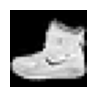

In [ ]:
show_image(img, figsize=(1,1));

In [ ]:
??collate_dict

Signature: collate_dict(ds)
Docstring: <no docstring>
Source:   
def collate_dict(ds):
  get = itemgetter(*ds.features)
  def _f(b): return get(default_collate(b))
  return _f
File:      ~/Documents/S07/40–49 Artificial Intelligence/42 Miniprojects/xiaoai/xiaoai/core.py
Type:      function

In [ ]:
cf = collate_dict(ds); cf

<function xiaoai.core.collate_dict.<locals>._f(b)>

In [ ]:
from torch.utils.data import DataLoader
from xiaoai.conv import to_device

In [ ]:
def collate_(b): return to_device(cf(b))
def data_loaders(dsd, bs, **kwargs): return {k:DataLoader(v, bs, **kwargs) for k,v in dsd.items()}

In [ ]:
dls = data_loaders(tdsd, bs, collate_fn=collate_)

In [ ]:
dlst, dlsv = dls['train'], dls['test']; dlst, dlsv

(<torch.utils.data.dataloader.DataLoader>,
 <torch.utils.data.dataloader.DataLoader>)

In [ ]:
from xiaoai.core import *
from xiaoai.conv import *

In [ ]:
with suplog(): xb,yb = next(iter(dlst))

Traceback (most recent call last):
  File "/Users/salmannaqvi/miniforge3/envs/default/lib/python3.11/site-packages/torch/utils/data/_utils/collate.py", line 155, in collate
    clone.update({key: collate([d[key] for d in batch], collate_fn_map=collate_fn_map) for key in elem})
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/salmannaqvi/miniforge3/envs/default/lib/python3.11/site-packages/torch/utils/data/_utils/collate.py", line 155, in <dictcomp>
    clone.update({key: collate([d[key] for d in batch], collate_fn_map=collate_fn_map) for key in elem})
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/salmannaqvi/miniforge3/envs/default/lib/python3.11/site-packages/torch/utils/data/_utils/collate.py", line 192, in collate
    raise TypeError(default_collate_err_msg_format.format(elem_type))
TypeError: default_collate: batch must contain tensors, numpy arrays, numbers

In [ ]:
tdsd['train'][0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=28x28>,
 'label': 9}

It seems that `transformi` is not working. 🤨

In [ ]:
??transformi

Signature: transformi(b)
Docstring: <no docstring>
Source:   
  def _f(b):
    f(b)
    return b
File:      ~/Documents/S07/40–49 Artificial Intelligence/42 Miniprojects/xiaoai/xiaoai/core.py
Type:      function

Upon further inspection, it's because after creating the list, I'm not assigning it back to the batch! Let's fix that.

In [ ]:
@inplace
def transformi(b): b[x] = [TF.to_tensor(o) for o in b[x]]

In [ ]:
tdsd = dsd.with_transform(transformi)
tdsd['train'][0]

{'image': tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000,

There! Working.

In [ ]:
ds = tdsd['train']
cf = collate_dict(ds)
dls = data_loaders(tdsd, bs, collate_fn=collate_)
dlst, dlsv = dls['train'], dls['test']; dlst, dlsv

(<torch.utils.data.dataloader.DataLoader>,
 <torch.utils.data.dataloader.DataLoader>)

In [ ]:
xb,yb = next(iter(dlst)); xb,yb

(tensor([[[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ...,
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.]]],
 
 
         ...,
 
 
         [[[0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           [0., 0., 0.,  ..., 0., 0., 0.],
           ..

In [ ]:
xb.shape, yb.shape

(torch.Size([256, 1, 28, 28]), torch.Size([256]))

In [ ]:
tdsd['train'].features

{'image': Image(mode=None, decode=True, id=None),
 'label': ClassLabel(names=['T - shirt / top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'], id=None)}

In [ ]:
from operator import itemgetter
lbl_getter = itemgetter(*yb[:16]); lbl_getter

operator.itemgetter(tensor(9, device='mps:0'), tensor(0, device='mps:0'), tensor(0, device='mps:0'), tensor(3, device='mps:0'), tensor(0, device='mps:0'), tensor(2, device='mps:0'), tensor(7, device='mps:0'), tensor(2, device='mps:0'), tensor(5, device='mps:0'), tensor(5, device='mps:0'), tensor(0, device='mps:0'), tensor(9, device='mps:0'), tensor(5, device='mps:0'), tensor(5, device='mps:0'), tensor(7, device='mps:0'), tensor(9, device='mps:0'))

In [ ]:
tdsd['train'].features['label'].names

['T - shirt / top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [ ]:
labels = lbl_getter(tdsd['train'].features['label'].names); labels

('Ankle boot',
 'T - shirt / top',
 'T - shirt / top',
 'Dress',
 'T - shirt / top',
 'Pullover',
 'Sneaker',
 'Pullover',
 'Sandal',
 'Sandal',
 'T - shirt / top',
 'Ankle boot',
 'Sandal',
 'Sandal',
 'Sneaker',
 'Ankle boot')

In [ ]:
?show_images

Signature:
show_images(
    ims: list,
    nrows: int | None = None,
    ncols: int | None = None,
    titles: list | None = None,
    *,
    figsize: tuple = None,
    imsize: int = 3,
    suptitle: str = None,
    sharex: "bool | Literal['none', 'all', 'row', 'col']" = False,
    sharey: "bool | Literal['none', 'all', 'row', 'col']" = False,
    squeeze: 'bool' = True,
    width_ratios: 'Sequence[float] | None' = None,
    height_ratios: 'Sequence[float] | None' = None,
    subplot_kw: 'dict[str, Any] | None' = None,
    gridspec_kw: 'dict[str, Any] | None' = None,
)
Docstring: Show all images `ims` as subplots with `rows` using `titles`
File:      ~/Documents/S07/40–49 Artificial Intelligence/42 Miniprojects/xiaoai/xiaoai/core.py
Type:      function

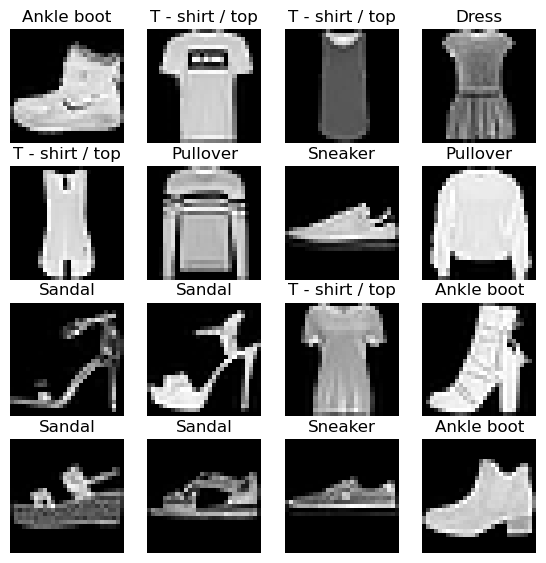

In [ ]:
show_images(xb[:16], titles=labels, imsize=1.7)

## Warmup - Classify

In [ ]:
from torch import nn
from xiaoai.conv import *

In [ ]:
cnn = nn.Sequential(
  conv( 1, 4), # 14x14
  conv( 4, 8), # 7x7
  conv( 8,16), # 4x4
  conv(16,16), # 2x2
  conv(16,10, act=False), # 1x1
  nn.Flatten()
).to(def_device)

In [ ]:
bs,lr = 256,.4

In [ ]:
from torch import optim

Init signature:
optim.SGD(
    params,
    lr: float = 0.001,
    momentum: float = 0,
    dampening: float = 0,
    weight_decay: float = 0,
    nesterov=False,
    *,
    maximize: bool = False,
    foreach: Optional[bool] = None,
    differentiable: bool = False,
    fused: Optional[bool] = None,
)
Docstring:     
Implements stochastic gradient descent (optionally with momentum).

.. math::
   \begin{aligned}
        &\rule{110mm}{0.4pt}                                                                 \\
        &\textbf{input}      : \gamma \text{ (lr)}, \: \theta_0 \text{ (params)}, \: f(\theta)
            \text{ (objective)}, \: \lambda \text{ (weight decay)},                          \\
        &\hspace{13mm} \:\mu \text{ (momentum)}, \:\tau \text{ (dampening)},
        \:\textit{ nesterov,}\:\textit{ maximize}                                     \\[-1.ex]
        &\rule{110mm}{0.4pt}                                                                 \\
        &\textbf{for} \: t=1

In [ ]:
?optim.SGD

In [ ]:
opt = optim.SGD(cnn.parameters(), lr=lr); opt

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.4
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [ ]:
from xiaoai.training import *

In [ ]:
??fit

Signature: fit(epochs, model, loss_func, opt, trn_dl, vld_dl)
Docstring: <no docstring>
Source:   
def fit(epochs, model, loss_func, opt, trn_dl, vld_dl):
  for epoch in range(epochs):
    model.train()
    for xb, yb in trn_dl:
      loss = loss_func(model(xb), yb)
      loss.backward()
      opt.step()
      opt.zero_grad()
    
    model.eval()
    with torch.no_grad():
      tot_loss, tot_acc, count = 0., 0., 0
      for xb, yb in vld_dl:
        preds = model(xb)
        n = len(xb)
        count += n
        tot_loss += loss_func(preds, yb).item() * n
        tot_acc  += accuracy (preds, yb).item() * n
    print(epoch, tot_loss/count, tot_acc/count)
  return tot_loss/count, tot_acc/count
File:      ~/Documents/S07/40–49 Artificial Intelligence/42 Miniprojects/xiaoai/xiaoai/training.py
Type:      function

In [ ]:
import torch.nn.functional as F

In [ ]:
loss,acc = fit(5, cnn, F.cross_entropy, opt, dlst, dlsv)

0 1.112137004852295 0.6341
1 0.6192411111831665 0.7772
2 0.5116905662536622 0.8181
3 0.511855121088028 0.815
4 0.5068988255739212 0.8156


# Autoencoder

In [ ]:
?nn.UpsamplingNearest2d

Init signature:
nn.UpsamplingNearest2d(
    size: Union[int, Tuple[int, int], NoneType] = None,
    scale_factor: Union[float, Tuple[float, float], NoneType] = None,
) -> None
Docstring:     
Applies a 2D nearest neighbor upsampling to an input signal composed of several input channels.

To specify the scale, it takes either the :attr:`size` or the :attr:`scale_factor`
as it's constructor argument.

When :attr:`size` is given, it is the output size of the image `(h, w)`.

Args:
    size (int or Tuple[int, int], optional): output spatial sizes
    scale_factor (float or Tuple[float, float], optional): multiplier for
        spatial size.

.. warning::
    This class is deprecated in favor of :func:`~nn.functional.interpolate`.

Shape:
    - Input: :math:`(N, C, H_{in}, W_{in})`
    - Output: :math:`(N, C, H_{out}, W_{out})` where

.. math::
      H_{out} = \left\lfloor H_{in} \times \text{scale\_factor} \right\rfloor

.. math::
      W_{out} = \left\lfloor W_{in} \times \text{scale\_fac

In [ ]:
from torch import tensor

In [ ]:
t = tensor([[1,2,3],[4,5,6]])[None,None,...].float(); t, t.shape

(tensor([[[[1., 2., 3.],
           [4., 5., 6.]]]]),
 torch.Size([1, 1, 2, 3]))

In [ ]:
upsample = nn.UpsamplingNearest2d(size=(4,6))

In [ ]:
?upsample

Signature:      upsample(*args, **kwargs)
Type:           UpsamplingNearest2d
String form:    UpsamplingNearest2d(size=(4, 6), mode='nearest')
File:           ~/miniforge3/envs/default/lib/python3.11/site-packages/torch/nn/modules/upsampling.py
Docstring:     
Applies a 2D nearest neighbor upsampling to an input signal composed of several input channels.

To specify the scale, it takes either the :attr:`size` or the :attr:`scale_factor`
as it's constructor argument.

When :attr:`size` is given, it is the output size of the image `(h, w)`.

Args:
    size (int or Tuple[int, int], optional): output spatial sizes
    scale_factor (float or Tuple[float, float], optional): multiplier for
        spatial size.

.. warning::
    This class is deprecated in favor of :func:`~nn.functional.interpolate`.

Shape:
    - Input: :math:`(N, C, H_{in}, W_{in})`
    - Output: :math:`(N, C, H_{out}, W_{out})` where

.. math::
      H_{out} = \left\lfloor H_{in} \times \text{scale\_factor} \right\rfloor



In [ ]:
upsample(t), upsample(t).shape

(tensor([[[[1., 1., 2., 2., 3., 3.],
           [1., 1., 2., 2., 3., 3.],
           [4., 4., 5., 5., 6., 6.],
           [4., 4., 5., 5., 6., 6.]]]]),
 torch.Size([1, 1, 4, 6]))

`nn.UpsamplingNearest2d` increases the spatial dimensions of a 2D input tensor through nearest neighbor interpolation. In other words, it duplicates the nearest pixel values with the `scale_factor` or `size` parameter.

In [ ]:
nn.UpsamplingNearest2d(scale_factor=2)(t)

tensor([[[[1., 1., 2., 2., 3., 3.],
          [1., 1., 2., 2., 3., 3.],
          [4., 4., 5., 5., 6., 6.],
          [4., 4., 5., 5., 6., 6.]]]])

The convolutoin process can be also be used as a compression method, since the shape of an image gets reduced. Therefore, the opposite can uncompress. In this way, an encoder or decoder of sorts can be created.

In [ ]:
def deconv(ni, nf, ks=3, act=True):
  layers = [nn.UpsamplingNearest2d(scale_factor=2),
            nn.Conv2d(ni, nf, stride=1, kernel_size=ks, padding=ks//2)]
  if act: layers.append(nn.ReLU())
  return nn.Sequential(*layers)

Here, a decoder has been implemented by increasing spatial dimensions, then applying a convolution to refine the upsampled dimensions.

In [ ]:
t = tensor([[1, 2, 3, 4],
           [5, 6, 7, 8],
           [9, 10, 11, 12],
           [13, 14, 15, 16]])[None,None,...].float(); t

tensor([[[[ 1.,  2.,  3.,  4.],
          [ 5.,  6.,  7.,  8.],
          [ 9., 10., 11., 12.],
          [13., 14., 15., 16.]]]])

In [ ]:
#| export
import torch
def eval(model, loss_func, valid_dl, epoch=0):
  model.eval()
  with torch.no_grad():
    loss, count = 0.,0
    for xb,_ in valid_dl:
      n = len(xb)
      count += n
      loss += loss_func(model(xb),xb).item()*n
  print(epoch, f'{loss/count:.3f}')


In [ ]:
def fit(epochs, model, loss_func, opt, train_dl, valid_dl):
  for epoch in range(epochs):
    model.train()
    for xb,_ in train_dl:
      loss = loss_func(model(xb), xb)
      loss.backward()
      opt.step()
      opt.zero_grad()
    eval(model, loss_func, valid_dl, epoch)

In [ ]:
?nn.ZeroPad2d

Init signature: nn.ZeroPad2d(padding: Union[int, Tuple[int, int, int, int]]) -> None
Docstring:     
Pads the input tensor boundaries with zero.

For `N`-dimensional padding, use :func:`torch.nn.functional.pad()`.

Args:
    padding (int, tuple): the size of the padding. If is `int`, uses the same
        padding in all boundaries. If a 4-`tuple`, uses (:math:`\text{padding\_left}`,
        :math:`\text{padding\_right}`, :math:`\text{padding\_top}`, :math:`\text{padding\_bottom}`)

Shape:
    - Input: :math:`(N, C, H_{in}, W_{in})` or :math:`(C, H_{in}, W_{in})`.
    - Output: :math:`(N, C, H_{out}, W_{out})` or :math:`(C, H_{out}, W_{out})`, where

      :math:`H_{out} = H_{in} + \text{padding\_top} + \text{padding\_bottom}`

      :math:`W_{out} = W_{in} + \text{padding\_left} + \text{padding\_right}`

Examples::

    >>> # xdoctest: +IGNORE_WANT("non-deterministic")
    >>> m = nn.ZeroPad2d(2)
    >>> input = torch.randn(1, 1, 3, 3)
    >>> input
    tensor([[[[-0.1678, -0.4418,  1.

Here, the input image will be compressed, before right after being uncompressed.

In [ ]:
ae = nn.Sequential( # 28x28
  nn.ZeroPad2d(2),  # 32x32
  conv(1,2),        # 16x16
  conv(2,4),        # 8x8
  deconv(4,2),      # 16x16
  deconv(2,1, act=False), #32x32
  nn.ZeroPad2d(-2), # 28x28
  nn.Sigmoid()
).to(def_device)

In [ ]:
eval(ae, F.mse_loss, dlsv)

0 0.162


In [ ]:
opt = optim.SGD(ae.parameters(), lr=0.01)

In [ ]:
#| eval: false
fit(5, ae, F.mse_loss, opt, dlst, dlsv)

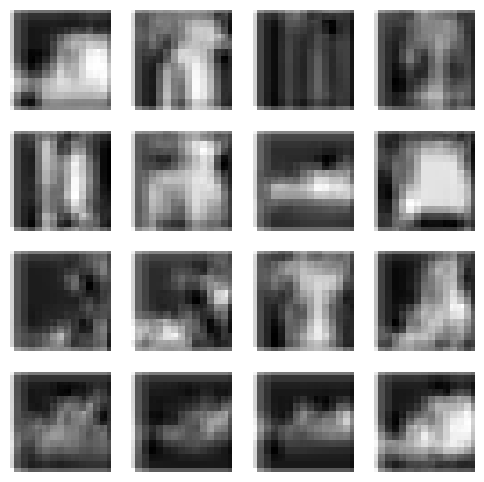

In [ ]:
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.127
1 0.126
2 0.125
3 0.125
4 0.125
5 0.124
6 0.124
7 0.124
8 0.124
9 0.124
10 0.124
11 0.124
12 0.124
13 0.124
14 0.124
15 0.124
16 0.124
17 0.124
18 0.124
19 0.124


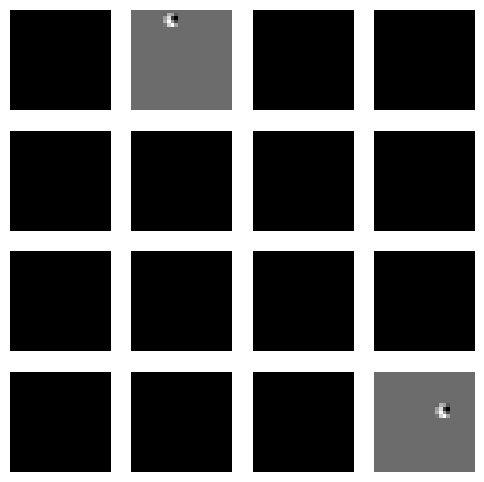

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=0.01)
fit(20, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.043
1 0.030
2 0.025
3 0.022
4 0.021


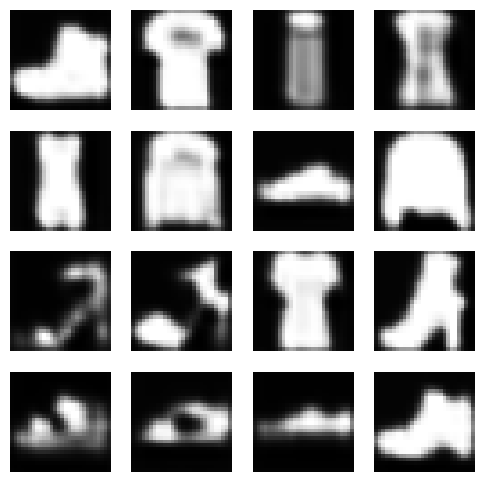

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=0.1)
fit(5, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.021
1 0.018
2 0.017
3 0.015
4 0.016


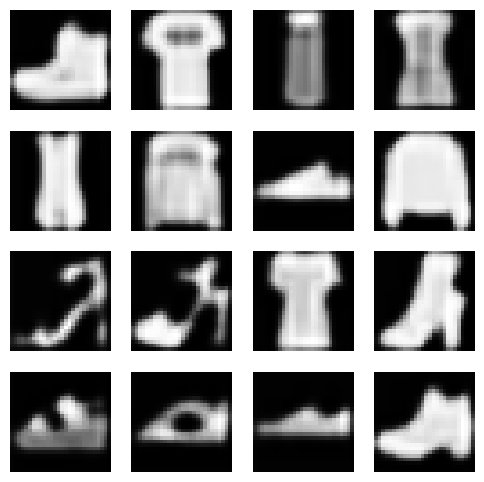

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=0.5)
fit(5, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.019
1 0.020
2 0.018
3 0.019
4 0.018


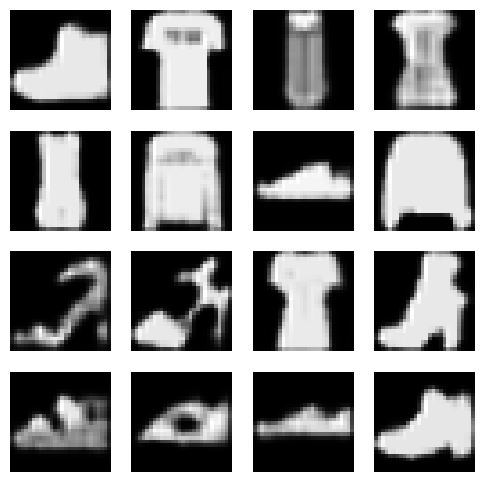

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=1)
fit(5, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.022
1 0.021
2 0.021
3 0.020
4 0.020


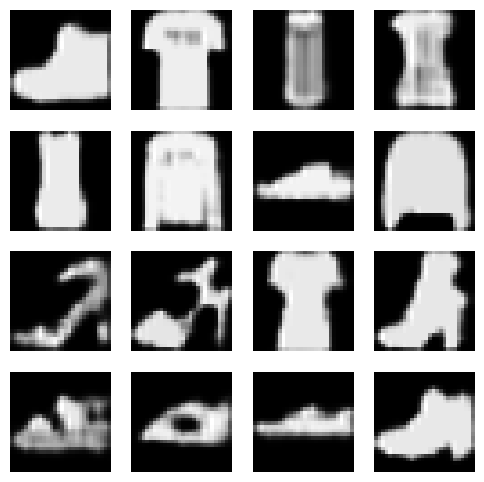

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=2)
fit(5, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.028
1 0.023
2 0.021
3 0.020
4 0.018
5 0.018
6 0.018
7 0.018
8 0.017
9 0.018


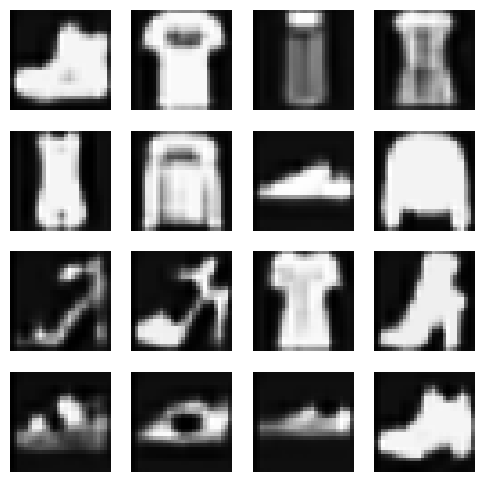

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=0.5)
fit(10, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

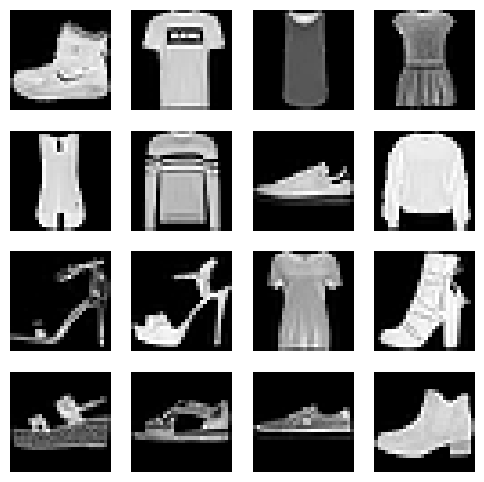

In [ ]:
show_images(xb[:16].data.cpu(), imsize=1.5)

In [ ]:
ae = nn.Sequential( # 28x28
  nn.ZeroPad2d(2),  # 32x32
  conv(1,2),        # 16x16
  conv(2,4),        # 8x8
  conv(4,8),        # 4x4
  deconv(8,4),      # 8x8
  deconv(4,2),      # 16x16
  deconv(2,1, act=False), #32x32
  nn.ZeroPad2d(-2), # 28x28
  nn.Sigmoid()
).to(def_device)

0 0.124
1 0.124
2 0.124
3 0.124
4 0.124
5 0.124
6 0.124
7 0.124
8 0.124
9 0.124


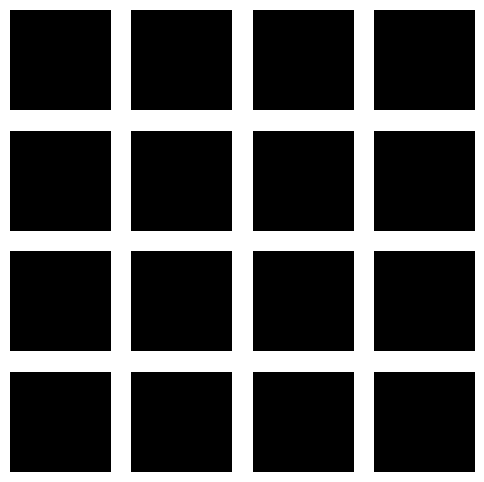

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=0.5)
fit(10, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.124
1 0.124
2 0.124
3 0.124
4 0.124


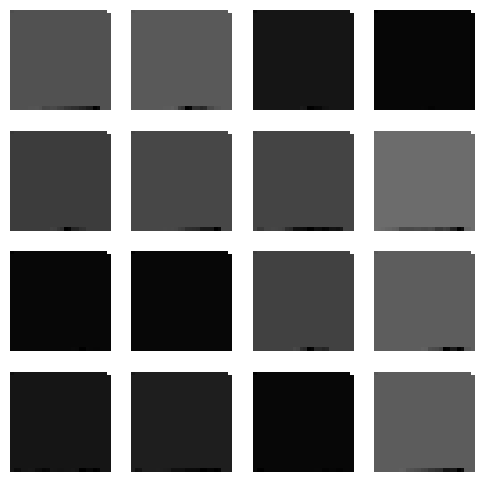

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=0.1)
fit(5, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

0 0.124
1 0.124
2 0.124
3 0.124
4 0.124


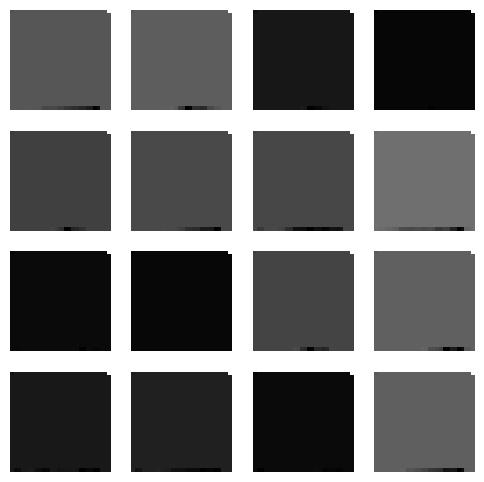

In [ ]:
#| eval: false
opt = optim.SGD(ae.parameters(), lr=0.01)
fit(5, ae, F.mse_loss, opt, dlst, dlsv)
p = ae(xb)
show_images(p[:16].data.cpu(), imsize=1.5)

## Export -

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export()